# Lecture 23: Deep Learning I — CNNs and Representation Learning

**F&W ECOL 458 — Environmental Data Science**

References: [Deep Learning book (Goodfellow et al.)](https://www.deeplearningbook.org/) | [Keras documentation](https://keras.io/)

---

### Learning objectives

By the end of this lecture, students will be able to:

1. Define what a "feature" is and distinguish between hand-engineered and learned features.
2. Represent images and multi-channel data as **tensors**.
3. Explain what makes a neural network "deep" and why depth enables representation learning.
4. Describe the encoder-decoder pattern that underlies most modern deep learning architectures.
5. Describe the core operations of convolutional neural networks (CNNs): convolution, pooling, and ReLU.


## 1. What Is a "Feature"?

We have used the word **feature** in every lecture so far — sometimes without pausing to define it carefully. Before we move into deep learning, let's make the concept precise, because deep learning changes fundamentally how we think about features.

### The classical definition

A **feature** is a measurable property of something we are trying to analyze. In the language of machine learning, it's one column in your data matrix $X$.

Every dataset we've worked with so far has features that were **already chosen and measured for us**. Someone decided these were the right things to record, and the numbers came to us in a spreadsheet:

| Dataset | Features | What kind of data are they? |
|---|---|---|
| Iris | sepal length, sepal width, petal length, petal width | 4 real-valued numbers per flower |
| SW radiation | SZA, AOD, COD, CLD_FRAC, UW, TO3, Pressure, BSA, WSA | 9 real-valued numbers per sample |
| Covertype | elevation, slope, aspect, hillshade, soil type, ... | Mix of continuous and binary indicators |

In each case, the raw reality (a flower, a patch of atmosphere, a pixel on a mountainside) was summarized into a fixed-size vector of numbers by *a human* who decided what to measure. The machine learning algorithm only ever sees those numbers.

### Features come in many types

The classical ML lectures we've seen focused on continuous numerical features, but features can be many things:

- **Continuous numerical:** temperature, NDVI, elevation, rainfall in mm
- **Discrete numerical:** count of species in a plot, number of rainy days per month
- **Categorical:** land cover class, species name, soil type (needs one-hot encoding)
- **Ordinal:** drought severity rating ("none / mild / moderate / severe"), ecological condition rank
- **Binary:** presence/absence, flag indicators (1 if burned, 0 otherwise)
- **Spatial:** latitude, longitude, elevation — but also *local context* like "distance to nearest road"
- **Temporal:** day of year, month, hour — or "days since last rain"
- **Text:** species name, habitat description, field notes
- **Image:** the pixels of a satellite patch, a camera trap photo, a microscope slide
- **Sequence:** time series of temperature, NDVI, or streamflow

Most of the work in traditional ecology research is **feature engineering**: deciding what to measure in the field, which variables to derive (NDVI from red and NIR bands, for example), and how to encode them for the algorithm.

### The fundamental challenge: what if you can't define the right features?

Imagine trying to classify a camera trap photo as "deer," "bear," or "no animal." Can you write down a formula for "is this photo a deer"? You could try:

- "Brown-colored blob?" — fails if the deer is backlit, or if there's a brown log in the frame.
- "Shape matches a four-legged animal?" — how do you encode "shape" as a number?
- "Ratio of certain pixel values?" — you'd need to discover which ones by tedious trial and error.

There's no clean feature vector that captures "deer-ness." The *useful* features — whatever lets our eyes recognize the deer — are not things we can easily list or compute. This is true of almost all image, audio, and text data.

This is where deep learning comes in: **rather than asking you to define features, a deep neural network learns them directly from the raw data.**

### Hand-engineered vs. learned features

Let's lay this out clearly:

| Approach | Features come from | Example |
|---|---|---|
| **Classical ML** | *You* — domain knowledge, intuition, trial and error | Compute NDVI from red and NIR bands, then feed to Random Forest |
| **Deep learning** | *The network* — learned automatically during training | Feed raw spectral bands to a CNN; it discovers that "NDVI-like" combinations are useful |

Classical ML separates the problem into two stages: feature engineering (hard, manual) and modeling (fit a function). Deep learning **merges the two** — the same network learns the features and the decision rule simultaneously, jointly optimized for the task. This is called **end-to-end learning** or **representation learning**.

The rest of this lecture is really about answering one question: **how does a neural network learn useful features from raw data like images?** The answer is the convolutional neural network.


## 2. Tensors: How We Represent Data Numerically

Before we can talk about the network's internal operations, we need a vocabulary for describing the data flowing through it. That vocabulary is the **tensor**.

### Scalars, vectors, matrices, and tensors

You've already used all of these, but under different names:

| Name | Shape | Example |
|---|---|---|
| Scalar | 0 dimensions — a single number | The temperature right now: `25.3` |
| Vector | 1 dimension — a list of numbers | Feature vector for one flower: `[5.1, 3.5, 1.4, 0.2]` |
| Matrix | 2 dimensions — a rectangle of numbers | A dataset: rows = samples, columns = features |
| **Tensor** | Any number of dimensions | Generalization of the above to 3D, 4D, ... |

A tensor is just the general term. A scalar is a 0-D tensor, a vector is a 1-D tensor, a matrix is a 2-D tensor, and when we go beyond that we just say "3-D tensor," "4-D tensor," and so on.

**Why do we care about going beyond 2-D?** Because images and time series are naturally higher-dimensional.


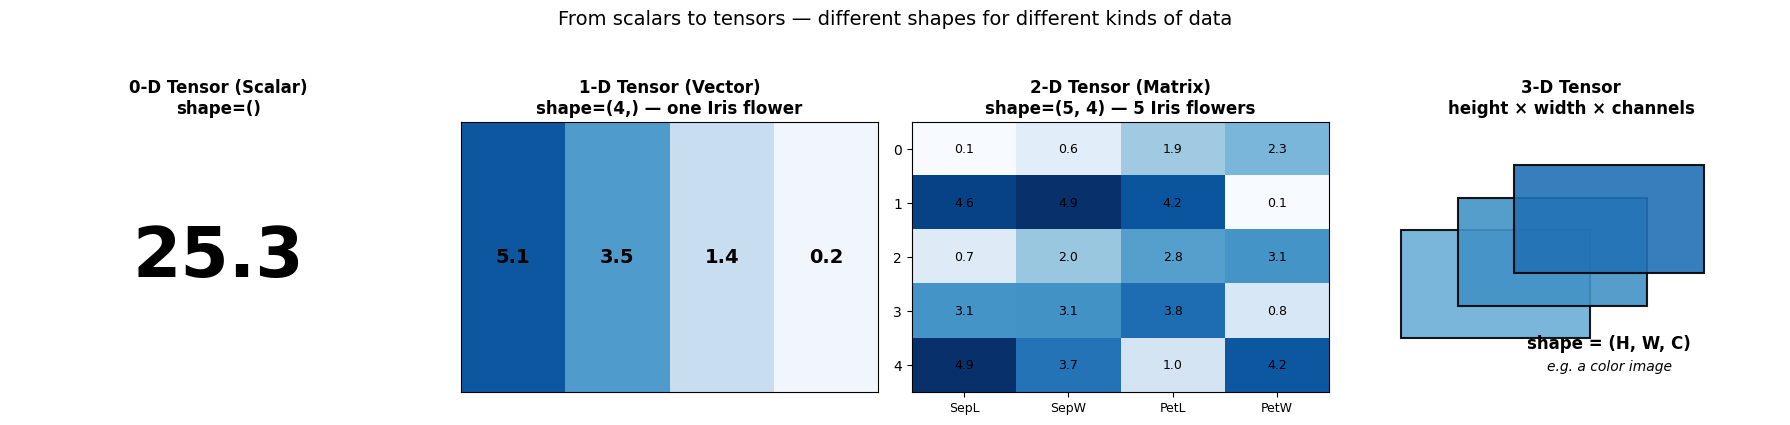

In [1]:
# ── Visualizing tensor dimensions ──
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 0-D: scalar
axes[0].text(0.5, 0.5, '25.3', ha='center', va='center', fontsize=50, fontweight='bold')
axes[0].set_title('0-D Tensor (Scalar)\nshape=()', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1); axes[0].axis('off')

# 1-D: vector
vec = np.array([5.1, 3.5, 1.4, 0.2])
axes[1].imshow(vec.reshape(1, -1), cmap='Blues', aspect='auto', vmin=0, vmax=6)
for i, v in enumerate(vec):
    axes[1].text(i, 0, f'{v:.1f}', ha='center', va='center', fontsize=14, fontweight='bold')
axes[1].set_title('1-D Tensor (Vector)\nshape=(4,) — one Iris flower', fontsize=12, fontweight='bold')
axes[1].set_xticks([]); axes[1].set_yticks([])

# 2-D: matrix
mat = np.random.rand(5, 4) * 5
axes[2].imshow(mat, cmap='Blues', aspect='auto')
for i in range(5):
    for j in range(4):
        axes[2].text(j, i, f'{mat[i,j]:.1f}', ha='center', va='center', fontsize=9)
axes[2].set_title('2-D Tensor (Matrix)\nshape=(5, 4) — 5 Iris flowers', fontsize=12, fontweight='bold')
axes[2].set_xticks(range(4)); axes[2].set_yticks(range(5))
axes[2].set_xticklabels(['SepL','SepW','PetL','PetW'], fontsize=9)

# 3-D: stacked matrices (tensor)
ax = axes[3]
# draw 3 stacked rectangles to suggest depth
for d, offset in enumerate([(0, 0), (0.15, 0.15), (0.3, 0.3)]):
    rect = plt.Rectangle((offset[0], offset[1]), 0.5, 0.5,
                         facecolor=['#6baed6', '#4292c6', '#2171b5'][d],
                         edgecolor='black', linewidth=1.5, alpha=0.9)
    ax.add_patch(rect)
ax.text(0.55, -0.05, 'shape = (H, W, C)', ha='center', fontsize=12, fontweight='bold')
ax.text(0.55, -0.15, 'e.g. a color image', ha='center', fontsize=10, style='italic')
ax.set_title('3-D Tensor\nheight × width × channels', fontsize=12, fontweight='bold')
ax.set_xlim(-0.1, 1); ax.set_ylim(-0.25, 1); ax.axis('off')

plt.suptitle('From scalars to tensors — different shapes for different kinds of data',
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


### Images as 3-D tensors

A grayscale image is a 2-D tensor: a matrix of pixel brightnesses. A color image adds a **channel** dimension — one layer for Red, one for Green, one for Blue — making it a 3-D tensor.

Think of a color image as three stacked matrices of the same size: a "Red matrix" with the red intensity of every pixel, a "Green matrix," and a "Blue matrix." The three together define the color at each position.


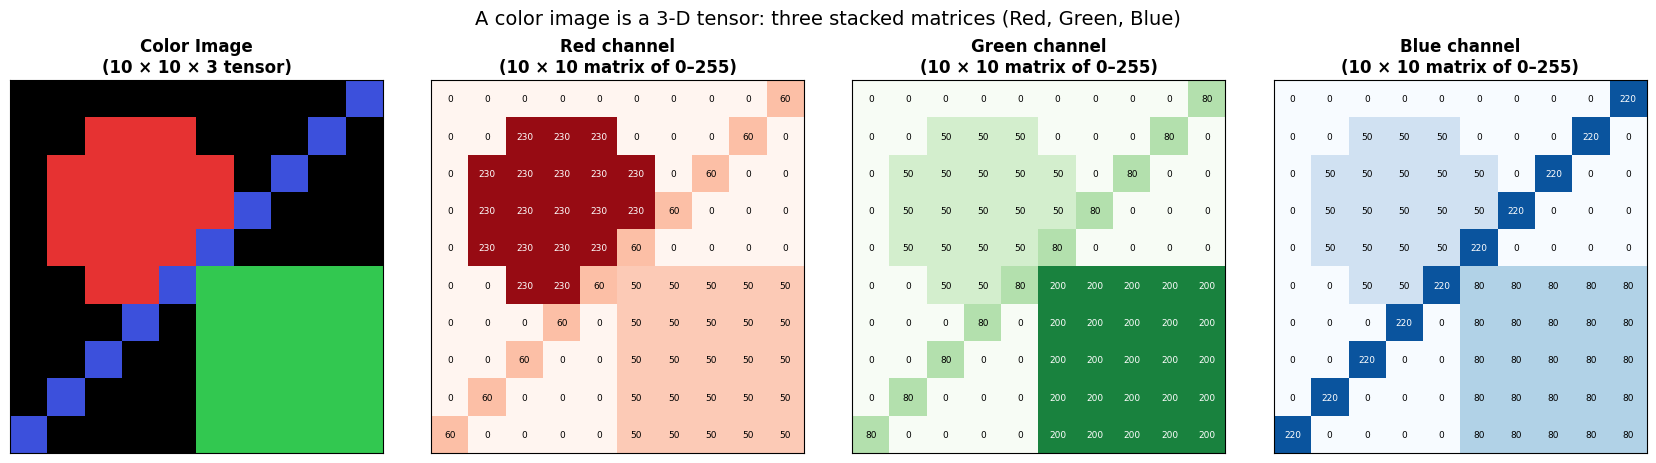

In [2]:
# ── How a color image is actually three stacked matrices ──
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Build a small synthetic color image (10x10 RGB)
np.random.seed(0)
img = np.zeros((10, 10, 3), dtype=np.uint8)
# Red circle in top-left
for i in range(10):
    for j in range(10):
        if (i-3)**2 + (j-3)**2 < 8:
            img[i,j] = [230, 50, 50]
# Green square bottom-right
for i in range(5, 10):
    for j in range(5, 10):
        img[i,j] = [50, 200, 80]
# Blue diagonal
for i in range(10):
    img[i, 9-i] = [60, 80, 220]

fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))

# Full color image
axes[0].imshow(img)
axes[0].set_title('Color Image\n(10 × 10 × 3 tensor)', fontsize=12, fontweight='bold')
axes[0].set_xticks([]); axes[0].set_yticks([])

# Separate channels
channel_names = ['Red channel', 'Green channel', 'Blue channel']
cmaps = ['Reds', 'Greens', 'Blues']
for i, (name, cmap) in enumerate(zip(channel_names, cmaps)):
    ax = axes[i+1]
    ax.imshow(img[:, :, i], cmap=cmap, vmin=0, vmax=255)
    # Annotate each pixel value
    for r in range(10):
        for c in range(10):
            val = img[r, c, i]
            color = 'white' if val > 120 else 'black'
            ax.text(c, r, str(val), ha='center', va='center',
                    fontsize=6.5, color=color)
    ax.set_title(f'{name}\n(10 × 10 matrix of 0–255)', fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('A color image is a 3-D tensor: three stacked matrices (Red, Green, Blue)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Notice the numbers inside each pixel — those are the actual values the network sees. The image is not magical to the network; it's just a 3-D tensor of shape $(H, W, C)$ where:

- $H$ = height in pixels
- $W$ = width in pixels  
- $C$ = number of channels (3 for RGB, 6 for Landsat, 13 for Sentinel-2, 200+ for hyperspectral)

A 224 × 224 RGB image contains $224 \times 224 \times 3 = 150{,}528$ numbers. A Landsat patch with 6 bands at the same resolution contains $301{,}056$ numbers. These are the inputs the network will process.

### Tensors across deep learning

Tensors are the universal data structure of deep learning. Here's what shows up at different stages:

| Data | Tensor shape | Example |
|---|---|---|
| One Iris flower | `(4,)` | a vector of 4 measurements |
| A batch of 32 Iris flowers | `(32, 4)` | rows × features |
| One grayscale MNIST digit | `(28, 28)` | a 2-D matrix of pixel intensities |
| One color image | `(H, W, 3)` | height × width × RGB channels |
| A batch of 64 color images | `(64, H, W, 3)` | batch × height × width × channels |
| One Landsat patch (6 bands) | `(H, W, 6)` | multi-channel spatial data |
| A time series of temperature | `(T,)` | a vector of T time steps |
| A batch of time series | `(batch, T, features)` | batch × time × features per step |

You'll see tensor shapes constantly when reading deep learning code. Always think: "what are the dimensions, and what does each one mean?" This habit makes deep learning code much easier to read.

### The bottom line for this lecture

- Features are whatever numbers you can feed to a machine learning model.
- Classical ML requires you to engineer the features. Deep learning learns them automatically from raw data.
- Deep learning organizes data as **tensors**, and for images the tensor shape is `(height, width, channels)`.

With this foundation, we can now talk about how a neural network actually *learns features* from an image tensor.


## 3. From Shallow Networks to Deep Representations

Last lecture we built neural networks with one or two hidden layers — **shallow networks**. These can in principle approximate any function, but they struggle when inputs have rich internal structure (like images).

**Deep learning** uses networks with many layers — often 10 to 100 or more. Each layer learns to transform the output of the previous one into progressively more abstract representations of the input.

### The feature hierarchy

Consider how your brain recognizes a bird in a photograph. You don't look at each pixel individually and think "bird." Your visual cortex extracts features at progressive scales:

| Level | What's detected | Neural network equivalent |
|---|---|---|
| Pixels | Raw light intensities | Input layer |
| Edges | Boundaries between light and dark | Early layers |
| Textures | Feathers, bark, sky patterns | Middle layers |
| Parts | Beaks, wings, eyes | Later layers |
| Objects | "This is a robin" | Output layer |

Each layer builds on what the previous one detected. Edges combine into textures. Textures combine into parts. Parts combine into objects. This mirrors how the visual cortex processes images in the brain — and remarkably, CNNs independently converge on a very similar hierarchy when trained from scratch on natural images.

### Representation learning: the key idea

A *representation* is how we encode information. The same photograph can be represented as:

- A 2-D array of pixel intensities (the raw image tensor)
- A histogram of colors (throws away spatial info)
- A list of detected edges (mid-level abstraction)
- A vector of object probabilities (high-level abstraction)
- A single word like "forest" (fully compressed)

Different representations are useful for different tasks. Pixel intensities are good for displaying the image; "forest" is good for classifying it.

Classical ML requires **you** to engineer the representation — compute NDVI, compute texture metrics, compute spectral indices. Deep learning **learns the representation from the data**, optimizing it end-to-end for the target task. This is why deep learning can work on data types (raw pixels, raw audio, raw text) where classical ML would require impossible amounts of feature engineering.


## 4. The Encoder-Decoder Pattern

Before diving into CNNs specifically, we need to introduce a design pattern that appears everywhere in modern deep learning: the **encoder-decoder** structure.

### The basic idea

An **encoder** takes raw, high-dimensional input (like an image) and compresses it into a smaller, more abstract representation — often called a **latent vector** or **embedding**. A **decoder** takes that compressed representation and produces the desired output (a classification, a reconstructed image, a translated sentence, and so on).

```
Input ────► [ENCODER] ────► compressed representation ────► [DECODER] ────► Output
(high-dim)                    (low-dim, abstract)                             (task-specific)
```


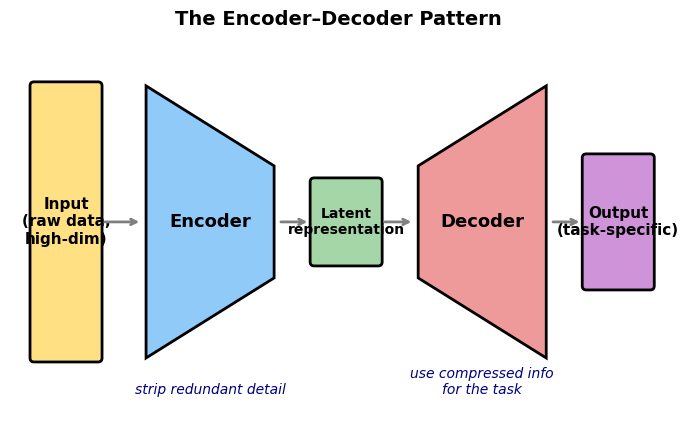

In [3]:
# ── Visualize the encoder-decoder pattern ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(13, 4.5))

# Input box (tall = high-dim)
ax.add_patch(mpatches.FancyBboxPatch((0.3, 0.3), 0.8, 3.4, boxstyle="round,pad=0.05",
                                       facecolor='#FFE082', edgecolor='black', linewidth=2))
ax.text(0.7, 2.0, 'Input\n(raw data,\nhigh-dim)', ha='center', va='center', fontsize=11, fontweight='bold')

# Encoder trapezoid
enc = mpatches.Polygon([[1.7, 0.3], [1.7, 3.7], [3.3, 2.7], [3.3, 1.3]],
                       closed=True, facecolor='#90CAF9', edgecolor='black', linewidth=2)
ax.add_patch(enc)
ax.text(2.5, 2.0, 'Encoder', ha='center', va='center', fontsize=13, fontweight='bold')

# Latent vector (short rectangle)
ax.add_patch(mpatches.FancyBboxPatch((3.8, 1.5), 0.8, 1.0, boxstyle="round,pad=0.05",
                                       facecolor='#A5D6A7', edgecolor='black', linewidth=2))
ax.text(4.2, 2.0, 'Latent\nrepresentation', ha='center', va='center', fontsize=10, fontweight='bold')

# Decoder trapezoid (mirror)
dec = mpatches.Polygon([[5.1, 1.3], [5.1, 2.7], [6.7, 3.7], [6.7, 0.3]],
                       closed=True, facecolor='#EF9A9A', edgecolor='black', linewidth=2)
ax.add_patch(dec)
ax.text(5.9, 2.0, 'Decoder', ha='center', va='center', fontsize=13, fontweight='bold')

# Output box
ax.add_patch(mpatches.FancyBboxPatch((7.2, 1.2), 0.8, 1.6, boxstyle="round,pad=0.05",
                                       facecolor='#CE93D8', edgecolor='black', linewidth=2))
ax.text(7.6, 2.0, 'Output\n(task-specific)', ha='center', va='center', fontsize=11, fontweight='bold')

# Arrows
for x1, x2 in [(1.15, 1.65), (3.35, 3.75), (4.65, 5.05), (6.75, 7.15)]:
    ax.annotate('', xy=(x2, 2.0), xytext=(x1, 2.0),
                arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

# Subtitles
ax.text(2.5, -0.15, 'strip redundant detail', ha='center', fontsize=10, style='italic', color='navy')
ax.text(5.9, -0.15, 'use compressed info\nfor the task', ha='center', fontsize=10, style='italic', color='navy')

ax.set_xlim(0, 8.2); ax.set_ylim(-0.6, 4.2)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('The Encoder–Decoder Pattern', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### Why this pattern is everywhere

Almost every deep learning architecture can be understood through the encoder-decoder lens:

| Architecture | Encoder's job | Decoder's job |
|---|---|---|
| Image classifier (CNN) | Compress image → feature vector | Map feature vector → class probabilities |
| Autoencoder | Compress image → latent code | Reconstruct the original image |
| U-Net (segmentation) | Compress image → feature map | Expand back to pixel-wise label map |
| Machine translation | Encode English sentence → meaning | Decode meaning → French sentence |
| Vision Transformer | Encode image patches → embeddings | Produce classification output |
| LLM (GPT) | Encode context → hidden state | Generate next token |

The encoder's job is always the same: **strip away irrelevant details and keep what's useful for the task**. The decoder's job is always to **use that compressed representation to produce the desired output**.

### Why compression helps

Raw data is mostly redundant. A 224×224 RGB image has 150,528 numbers, but the *meaningful content* ("there is a cat in the upper left") can be captured in far fewer dimensions. By forcing the network to compress, we push it to keep only what matters for the task.

This is conceptually similar to **PCA** from Lecture 19 — PCA finds a lower-dimensional representation that preserves variance. Encoder-decoder networks do the same thing, but the compression is **learned end-to-end for a specific task** rather than following a fixed mathematical rule.

### Where we're going

The CNN we'll build in a moment is exactly this structure: **convolutional layers are the encoder** (compressing the image into a feature vector), **followed by a small fully-connected decoder** (mapping that feature vector to a class label). Keep this structure in mind as we walk through the details.


## 5. Convolutional Neural Networks (CNNs)

### The motivating problem

Why don't we just feed images into a fully connected network and call it done? Consider a single 224×224 RGB image. That's 150,528 input pixels. A fully connected layer with 512 neurons would need about **77 million weights** *just for the first layer*.

Worse, a fully connected network treats each pixel as an independent input. It ignores two facts that we know intuitively about images:

1. **Local structure matters.** A pixel is most related to its neighbors, not to pixels on the far side of the image.
2. **Translation invariance.** A cat is a cat whether it appears in the top-left corner or the bottom-right. We want the network to recognize the same feature regardless of location.

A fully connected network has no built-in way to exploit these facts. It has to learn them from scratch, which is wasteful.

**CNNs solve both problems by encoding these assumptions directly into the architecture.**


### The convolution operation

A **convolution** is a small sliding window — called a **filter** or **kernel** — that moves across the image. At each position, it computes a weighted sum of the pixels it covers and produces one output value. Think of it as a moving magnifying glass that inspects a small patch of the image at a time.

Let's walk through a convolution explicitly.


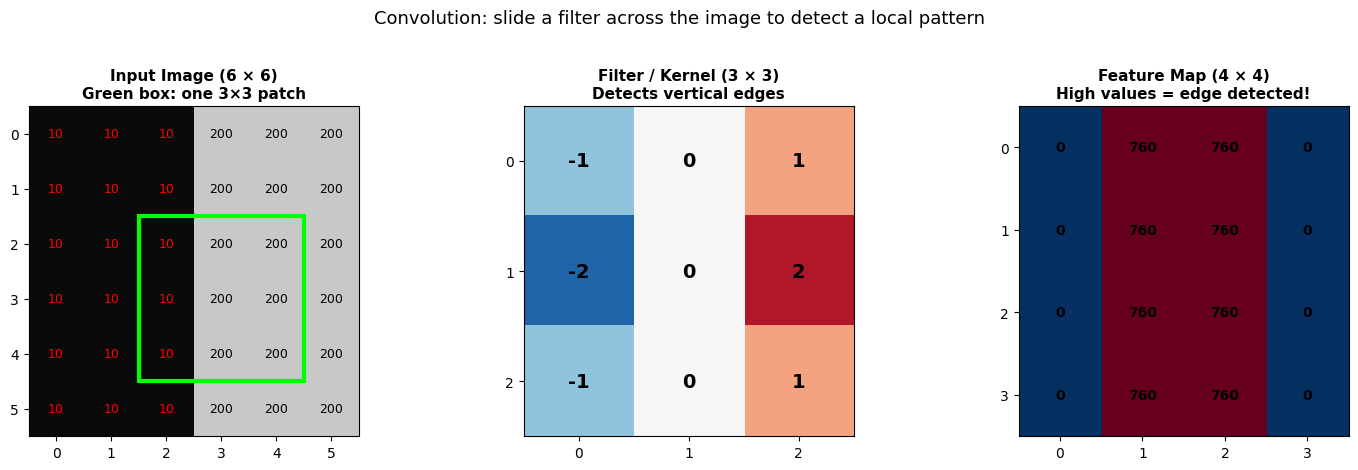

At position (row=2, col=2) of the feature map:
  Image patch:
[[ 10 200 200]
 [ 10 200 200]
 [ 10 200 200]]
  Elementwise product with kernel:
  [[-10   0 200]
 [-20   0 400]
 [-10   0 200]]
  Sum: 760

The large positive value at the edge column tells us: 'there is a strong vertical edge here.'


In [4]:
# ── Demonstrate a convolution step by step ──
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Small 6x6 grayscale "image" with a vertical edge
image = np.array([
    [10, 10, 10, 200, 200, 200],
    [10, 10, 10, 200, 200, 200],
    [10, 10, 10, 200, 200, 200],
    [10, 10, 10, 200, 200, 200],
    [10, 10, 10, 200, 200, 200],
    [10, 10, 10, 200, 200, 200],
], dtype=float)

# Vertical edge detector kernel (classic Sobel-like)
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=float)

# Compute full convolution output
def conv2d(img, k):
    kh, kw = k.shape
    ih, iw = img.shape
    out_h, out_w = ih - kh + 1, iw - kw + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i, j] = (img[i:i+kh, j:j+kw] * k).sum()
    return out

feature_map = conv2d(image, kernel)

# Plot image, kernel, and feature map
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Input image
axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
for i in range(6):
    for j in range(6):
        axes[0].text(j, i, int(image[i,j]), ha='center', va='center',
                     color='red' if image[i,j] < 128 else 'black', fontsize=9)
# Highlight the 3x3 patch we'll convolve
rect = Rectangle((1.5, 1.5), 3, 3, fill=False, edgecolor='lime', linewidth=3)
axes[0].add_patch(rect)
axes[0].set_title('Input Image (6 × 6)\nGreen box: one 3×3 patch',
                  fontsize=11, fontweight='bold')
axes[0].set_xticks(range(6)); axes[0].set_yticks(range(6))

# Kernel
axes[1].imshow(kernel, cmap='RdBu_r', vmin=-2.5, vmax=2.5)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, int(kernel[i,j]), ha='center', va='center',
                     fontsize=14, fontweight='bold')
axes[1].set_title('Filter / Kernel (3 × 3)\nDetects vertical edges',
                  fontsize=11, fontweight='bold')
axes[1].set_xticks(range(3)); axes[1].set_yticks(range(3))

# Feature map
axes[2].imshow(feature_map, cmap='RdBu_r')
for i in range(feature_map.shape[0]):
    for j in range(feature_map.shape[1]):
        axes[2].text(j, i, f'{int(feature_map[i,j])}', ha='center', va='center',
                     fontsize=10, fontweight='bold')
axes[2].set_title(f'Feature Map ({feature_map.shape[0]} × {feature_map.shape[1]})\nHigh values = edge detected!',
                  fontsize=11, fontweight='bold')
axes[2].set_xticks(range(feature_map.shape[1]))
axes[2].set_yticks(range(feature_map.shape[0]))

plt.suptitle('Convolution: slide a filter across the image to detect a local pattern',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

# Show the math for one position
print("At position (row=2, col=2) of the feature map:")
patch = image[2:5, 2:5]
print(f"  Image patch:\n{patch.astype(int)}")
print(f"  Elementwise product with kernel:")
print(f"  {(patch * kernel).astype(int)}")
print(f"  Sum: {(patch * kernel).sum():.0f}")
print(f"\nThe large positive value at the edge column tells us: "
      f"'there is a strong vertical edge here.'")


Walk through what just happened:

1. The **input** is a 6×6 image with a clear vertical edge running down the middle (dark on the left, bright on the right).
2. The **kernel** has negative values on the left column, zero in the middle, positive values on the right. This is a classic "vertical edge detector."
3. The **feature map** shows where the kernel responded strongly. Low values (dark blue) everywhere except at the edge position — where we get large positive values. The kernel successfully detected the edge.

**Two facts to internalize:**

- The same 3×3 kernel is used at every position. This is **weight sharing** — the defining property that makes CNNs efficient.
- The kernel has only 9 numbers. A CNN filter is tiny; it can only see a small local patch. Nevertheless, by stacking many such filters in sequence, the network can detect arbitrarily complex patterns.

### Learned filters

In the example above, I chose the kernel by hand — I wrote the 9 numbers that detect a vertical edge. In a real CNN, **the 9 numbers are learned from data**. The network is told "classify these images correctly," and backpropagation figures out what the kernel weights should be. Remarkably, networks trained from scratch on natural images almost always discover edge and color detectors in their first layer — just like the hand-designed one above.


### Feature maps: the output of convolution

A convolutional *layer* doesn't use just one kernel — it uses many in parallel, typically 32 or 64. Each kernel produces one **feature map**, and the layer's output is the stack of all of them.

If you apply 64 different 3×3 kernels to a 224×224 input, the output is a tensor of shape `(224, 224, 64)` — still 2-D spatially, but now with 64 channels, each representing where a different learned pattern appeared.

Think of it as: the input had 3 channels (R, G, B), and after one convolutional layer it has 64 channels (one per learned pattern). Each successive layer extracts more abstract patterns from the patterns below.


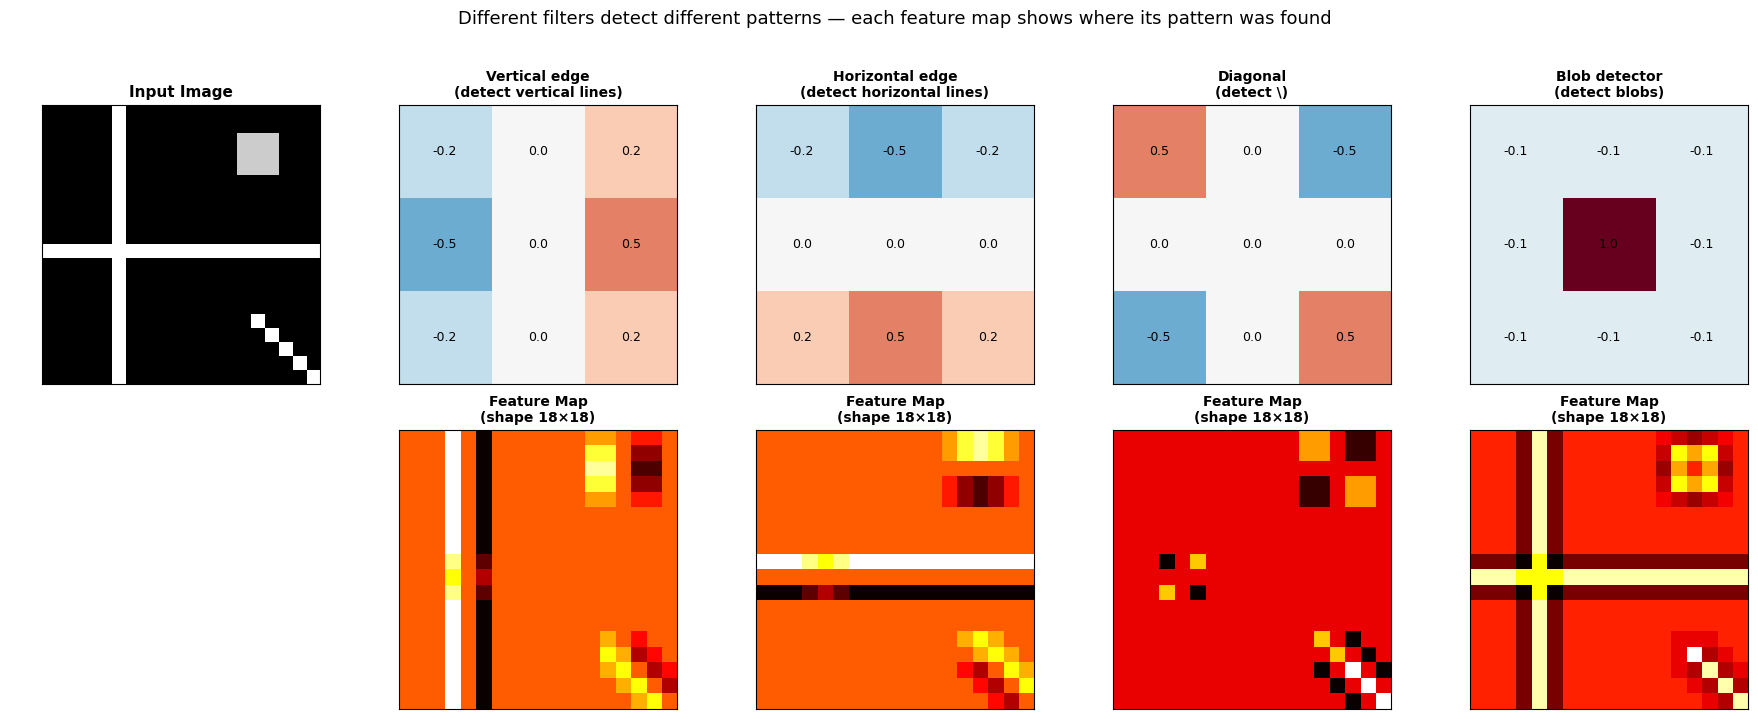

In [5]:
# ── Visualize filters applied to a real-ish image ──
import numpy as np
import matplotlib.pyplot as plt

# Create a more interesting synthetic image
image = np.zeros((20, 20))
# Vertical line at x=5
image[:, 5] = 1.0
# Horizontal line at y=10
image[10, :] = 1.0
# Diagonal from (15,15) to (19,19)
for i in range(5):
    image[15+i, 15+i] = 1.0
# Small blob
image[2:5, 14:17] = 0.8

# Four different hand-designed filters
filters = {
    'Vertical edge\n(detect vertical lines)': np.array([[-1,0,1],[-2,0,2],[-1,0,1]]) / 4,
    'Horizontal edge\n(detect horizontal lines)': np.array([[-1,-2,-1],[0,0,0],[1,2,1]]) / 4,
    'Diagonal\n(detect \\)': np.array([[1,0,-1],[0,0,0],[-1,0,1]]) / 2,
    'Blob detector\n(detect blobs)': np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]) / 8,
}

def conv2d(img, k):
    kh, kw = k.shape
    ih, iw = img.shape
    out = np.zeros((ih - kh + 1, iw - kw + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = (img[i:i+kh, j:j+kw] * k).sum()
    return out

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
# Show input in first column spanning both rows
axes[0,0].imshow(image, cmap='gray')
axes[0,0].set_title('Input Image', fontsize=11, fontweight='bold')
axes[0,0].set_xticks([]); axes[0,0].set_yticks([])
axes[1,0].axis('off')

# Show each filter + result
for col_idx, (name, kernel) in enumerate(filters.items()):
    fmap = conv2d(image, kernel)
    # Filter (top row)
    ax_k = axes[0, col_idx+1]
    ax_k.imshow(kernel, cmap='RdBu_r', vmin=-1, vmax=1)
    for i in range(3):
        for j in range(3):
            ax_k.text(j, i, f'{kernel[i,j]:.1f}', ha='center', va='center', fontsize=9)
    ax_k.set_title(name, fontsize=10, fontweight='bold')
    ax_k.set_xticks([]); ax_k.set_yticks([])
    # Feature map (bottom row)
    ax_f = axes[1, col_idx+1]
    ax_f.imshow(fmap, cmap='hot')
    ax_f.set_title(f'Feature Map\n(shape {fmap.shape[0]}×{fmap.shape[1]})',
                   fontsize=10, fontweight='bold')
    ax_f.set_xticks([]); ax_f.set_yticks([])

plt.suptitle('Different filters detect different patterns — each feature map shows where its pattern was found',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Each filter extracts a different kind of information. In a real CNN, the filters are *learned* — and with 32 or 64 filters per layer, the network discovers an enormous vocabulary of local patterns relevant to the task.

### Pooling: reducing spatial size

After a convolutional layer, we typically apply a **pooling** operation to shrink the spatial dimensions. The most common is **max pooling**: for each 2×2 block, keep only the maximum value. This:

- **Reduces computation by 4×** — a 2×2 pool replaces 4 values with 1.
- **Provides translation invariance** — small shifts in the input don't change the output much.
- **Forces focus on the strongest signals** — only the most active positions survive.


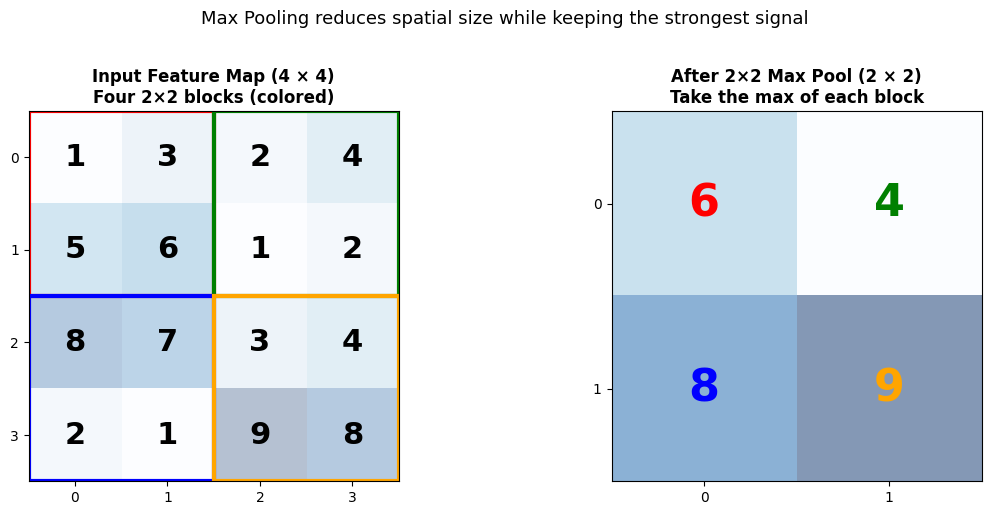

Block (0,0): max of [[1,3],[5,6]] = 6
Block (0,1): max of [[2,4],[1,2]] = 4
Block (1,0): max of [[8,7],[2,1]] = 8
Block (1,1): max of [[3,4],[9,8]] = 9


In [6]:
# ── Visualize max pooling ──
import numpy as np
import matplotlib.pyplot as plt

# Example 4x4 feature map
fmap = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [8, 7, 3, 4],
    [2, 1, 9, 8],
], dtype=float)

# Max pooled result
pooled = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        pooled[i, j] = fmap[2*i:2*i+2, 2*j:2*j+2].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Input with 2x2 colored regions
colors = [['#FFCDD2', '#C8E6C9'], ['#BBDEFB', '#FFE082']]
axes[0].imshow(fmap, cmap='Blues', alpha=0.3)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, int(fmap[i,j]), ha='center', va='center',
                     fontsize=22, fontweight='bold')
# Draw 2x2 boxes
from matplotlib.patches import Rectangle
for block_i in range(2):
    for block_j in range(2):
        rect = Rectangle((block_j*2-0.5, block_i*2-0.5), 2, 2,
                         fill=False, edgecolor=['red','green','blue','orange'][block_i*2+block_j],
                         linewidth=3)
        axes[0].add_patch(rect)
axes[0].set_title('Input Feature Map (4 × 4)\nFour 2×2 blocks (colored)',
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(range(4)); axes[0].set_yticks(range(4))

# Pooled output
axes[1].imshow(pooled, cmap='Blues', alpha=0.5)
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, int(pooled[i,j]), ha='center', va='center',
                     fontsize=32, fontweight='bold',
                     color=['red','green','blue','orange'][i*2+j])
axes[1].set_title('After 2×2 Max Pool (2 × 2)\nTake the max of each block',
                  fontsize=12, fontweight='bold')
axes[1].set_xticks(range(2)); axes[1].set_yticks(range(2))

plt.suptitle('Max Pooling reduces spatial size while keeping the strongest signal',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Block (0,0): max of [[1,3],[5,6]] = 6")
print("Block (0,1): max of [[2,4],[1,2]] = 4")
print("Block (1,0): max of [[8,7],[2,1]] = 8")
print("Block (1,1): max of [[3,4],[9,8]] = 9")


### ReLU: the nonlinearity

Between convolutions, we apply a simple nonlinearity called **ReLU** (Rectified Linear Unit):

$$
\text{ReLU}(x) = \max(0, x)
$$

Negative values become zero; positive values pass through unchanged. Without this nonlinearity, stacking many linear operations would collapse into a single linear operation — defeating the purpose of depth. ReLU is simple, fast, and works remarkably well.

### Putting it together

A CNN stacks these operations into alternating blocks:

```
Input Image (H × W × 3)
  → [Conv → ReLU → Pool]     # Block 1: detect low-level features
  → [Conv → ReLU → Pool]     # Block 2: detect mid-level features
  → [Conv → ReLU → Pool]     # Block 3: detect high-level features
  → Flatten
  → [Fully Connected → ReLU]  # Dense classification layers
  → Output (Softmax)
```

The convolutional blocks are the **encoder** — they compress the image into a compact feature representation. The fully connected layers at the end are the **decoder** — they map that representation into the desired output.


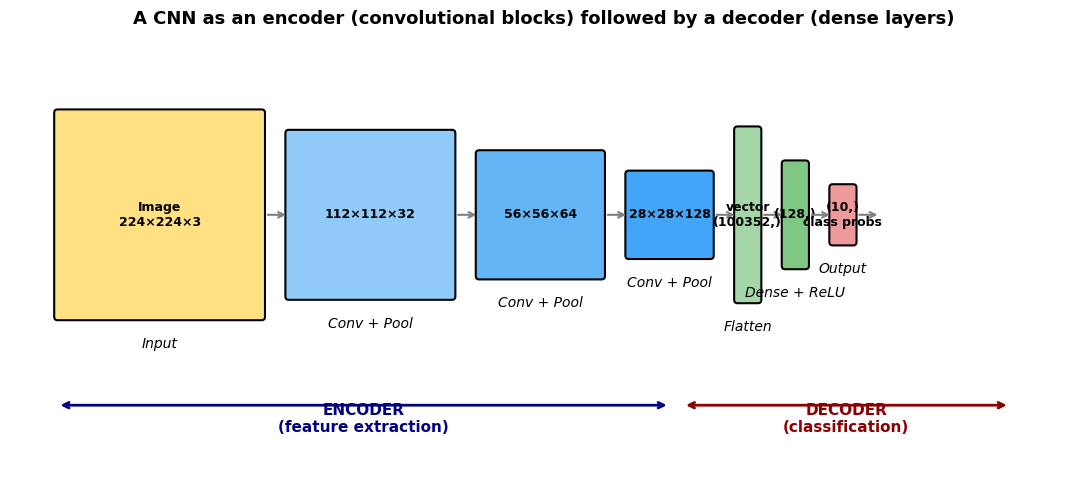

In [7]:
# ── Visualize the CNN architecture as a pipeline ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(17, 5))

# Define blocks with their sizes (shrinking spatial, growing channels)
blocks = [
    ('Input',        3.0, 3.0, 0.3, '#FFE082', 'Image\n224×224×3'),
    ('Conv + Pool',  2.4, 2.4, 0.6, '#90CAF9', '112×112×32'),
    ('Conv + Pool',  1.8, 1.8, 0.9, '#64B5F6', '56×56×64'),
    ('Conv + Pool',  1.2, 1.2, 1.2, '#42A5F5', '28×28×128'),
    ('Flatten',      0.3, 2.5, 0.2, '#A5D6A7', 'vector\n(100352,)'),
    ('Dense + ReLU', 0.3, 1.5, 0.2, '#81C784', '(128,)'),
    ('Output',       0.3, 0.8, 0.2, '#EF9A9A', '(10,)\nclass probs'),
]

x = 0.5
for name, w, h, d, color, shape_label in blocks:
    y_center = 2.5
    rect = mpatches.FancyBboxPatch((x, y_center - h/2), w, h,
                                     boxstyle="round,pad=0.05",
                                     facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y_center, shape_label, ha='center', va='center',
            fontsize=9, fontweight='bold')
    ax.text(x + w/2, y_center - h/2 - 0.3, name, ha='center', va='top',
            fontsize=10, style='italic')
    x += w + 0.4
    if x < 14:
        ax.annotate('', xy=(x, y_center), xytext=(x - 0.35, y_center),
                    arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))

# Encoder / decoder brackets
ax.annotate('', xy=(0.5, -0.3), xytext=(9.5, -0.3),
            arrowprops=dict(arrowstyle='<->', lw=2, color='navy'))
ax.text(5, -0.7, 'ENCODER\n(feature extraction)', ha='center', fontsize=11,
        fontweight='bold', color='navy')

ax.annotate('', xy=(9.7, -0.3), xytext=(14.5, -0.3),
            arrowprops=dict(arrowstyle='<->', lw=2, color='darkred'))
ax.text(12.1, -0.7, 'DECODER\n(classification)', ha='center', fontsize=11,
        fontweight='bold', color='darkred')

ax.set_xlim(-0.2, 15.5); ax.set_ylim(-1.4, 5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('A CNN as an encoder (convolutional blocks) followed by a decoder (dense layers)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### Why depth matters: the learned feature hierarchy

Here's the remarkable thing about stacking convolutional layers: each layer operates on the output of the previous one, so each layer sees **combinations** of what the previous layer detected.

| Layer | What it learns to detect |
|---|---|
| Layer 1 | Simple patterns: edges, color gradients, dots |
| Layer 2 | Textures and simple shapes — combinations of edges |
| Layer 3 | Object parts — combinations of textures (a wheel, a feather, an eye) |
| Deeper layers | Whole objects — combinations of parts (a bird, a tree, a building) |

**Nobody programs these features — the network discovers them from the data.** This is representation learning in action.

### Ecological analogy

Think of CNN layers as a series of surveys at increasing spatial scales:

| Layer | Scale | What it detects |
|---|---|---|
| Layer 1 | Individual pixels | Reflectance differences, shadow edges |
| Layer 2 | Small patches (~10 m) | Canopy roughness, water smoothness |
| Layer 3 | Larger patches (~30 m) | Tree crowns, field rows, building outlines |
| Final layers | Whole image | Land-cover class, habitat type |

This hierarchical feature extraction is exactly why CNNs are so powerful for remote sensing — the network's internal structure matches how spatial patterns actually manifest in Earth observation data.


## 6. Building and Training a CNN in Keras

Let's build and train a CNN on CIFAR-10 (60,000 32×32 color images across 10 classes). The same workflow applies directly to satellite imagery or camera trap photos.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training tensor shape: (50000, 32, 32, 3)  →  (60000 images, 32×32, 3 channels)
Test tensor shape:     (10000, 32, 32, 3)


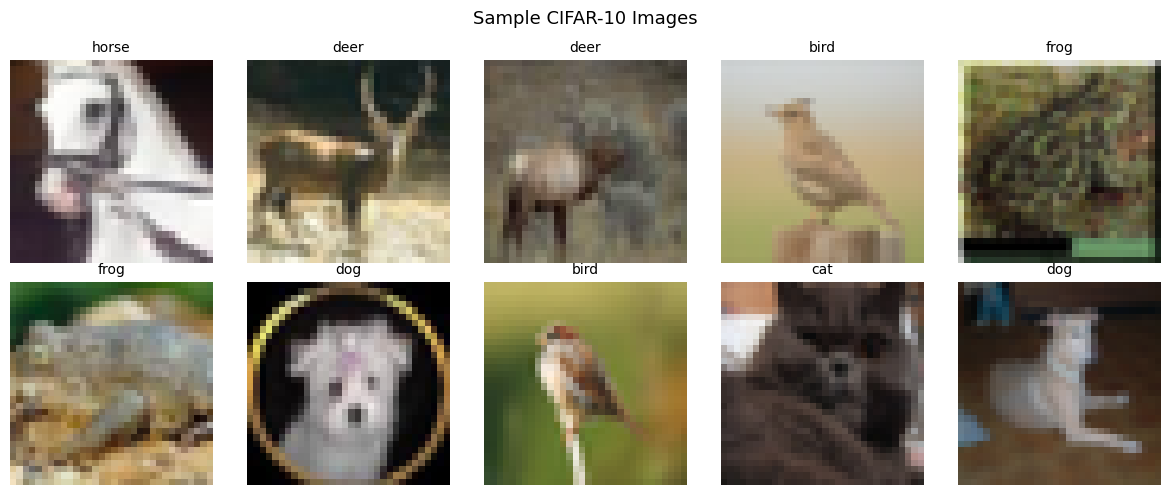

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# ── Load CIFAR-10 ──
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train = X_train.astype('float32') / 255.0   # normalize pixel values to [0,1]
X_test = X_test.astype('float32') / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f"Training tensor shape: {X_train.shape}  →  (60000 images, 32×32, 3 channels)")
print(f"Test tensor shape:     {X_test.shape}")

# ── Visualize sample images ──
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(X_train))
    ax.imshow(X_train[idx])
    ax.set_title(class_names[y_train[idx]], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=13)
plt.tight_layout()
plt.show()


In [9]:
# ── Define a simple CNN ──
# Note the encoder–decoder structure:
#   Convolutional blocks ENCODE the image into a feature representation
#   Dense layers DECODE that representation into class probabilities

model = keras.Sequential([
    # === ENCODER: feature extraction ===
    # Block 1: detect low-level features (edges, colors)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),            # 32x32 → 16x16
    layers.Dropout(0.25),

    # Block 2: detect mid-level features (textures, shapes)
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),            # 16x16 → 8x8
    layers.Dropout(0.25),

    # === DECODER: classification ===
    layers.Flatten(),                        # 8x8x64 → 4096 vector
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')   # 10 class probabilities
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

Read through `model.summary()`. It shows the tensor shape at every layer:

- Input: `(None, 32, 32, 3)` — a batch of 32×32 RGB images (the `None` is the batch dimension).
- After Conv2D with `padding='same'`: spatial size stays 32×32, but channels increase from 3 to 32 (one feature map per filter).
- After MaxPool: spatial size halves (32→16, then 16→8).
- After Flatten: the `8×8×64` tensor becomes a `4096`-dimensional vector — this is the **encoded representation** of the image.
- Dense layers progressively map this vector down to 10 class probabilities.

The total parameter count is far less than a fully connected network would need for the same task, thanks to weight sharing in the conv layers.


In [10]:
# ── Compile and train ──
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=10, batch_size=64,
                    validation_split=0.1, verbose=1)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.2%}")


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 237s 332ms/step - accuracy: 0.3605 - loss: 1.7403 - val_accuracy: 0.5056 - val_loss: 1.3419
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 229s 326ms/step - accuracy: 0.5097 - loss: 1.3659 - val_accuracy: 0.5956 - val_loss: 1.1132
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 263s 327ms/step - accuracy: 0.5700 - loss: 1.2065 - val_accuracy: 0.6378 - val_loss: 1.0141
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 231s 328ms/step - accuracy: 0.6136 - loss: 1.0981 - val_accuracy: 0.6764 - val_loss: 0.9234
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 229s 326ms/step - accuracy: 0.6434 - loss: 1.0130 - val_accuracy: 0.7118 - val_loss: 0.8202
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 265s 330ms/step - accuracy: 0.6635 - loss: 0.9540 - val_accuracy: 0.7256 - val_loss: 0.7838
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 264s 334ms/step - accuracy: 0.6822 - loss: 0.9088 - val_accuracy: 0.7420 - val_loss: 0.7472
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 264s 336ms/step - accuracy: 0.6970 -

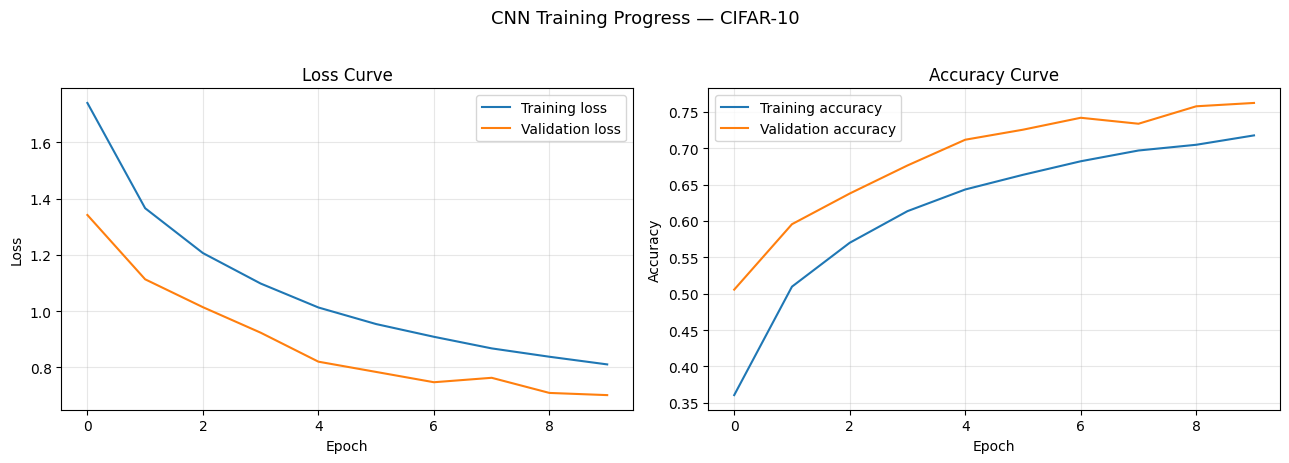

In [11]:
# ── Training curves ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history.history['loss'], label='Training loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('CNN Training Progress — CIFAR-10', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


With only 10 epochs and a simple architecture, we achieve roughly 70% test accuracy on CIFAR-10 — a task that would be nearly impossible with classical ML without elaborate hand-engineered features. Deeper CNNs with more training can reach 95%+.

Notice how the validation loss starts to flatten while training loss keeps dropping — that's mild overfitting beginning to appear. Regularization techniques like dropout (already in our model), data augmentation, and early stopping are what prevent it from getting worse.


## 7. Summary

| Concept | Key takeaway |
|---|---|
| Feature | A measurable property of the data; can be continuous, categorical, spatial, temporal, text, image |
| Tensor | Generalization of scalar/vector/matrix to any number of dimensions; images are 3-D tensors |
| Representation learning | Deep networks learn features automatically from raw data rather than requiring hand engineering |
| Encoder-decoder | Compress input → compact representation → produce task-specific output (a universal pattern) |
| Convolution | Sliding filter detects local patterns with shared weights across the image |
| Feature map | Output of a convolutional layer; each channel encodes a different learned pattern |
| Pooling | Downsamples spatial dimensions, providing some translation invariance |
| ReLU | Simple nonlinearity that makes stacked layers meaningful |
| Feature hierarchy | Early layers learn edges; deep layers learn objects; emerges from the data |

### When to use CNNs

Reach for a CNN when:

- Your data consists of **images** — satellite patches, drone imagery, camera trap photos, microscope images.
- You want **end-to-end learning** from raw pixels without manual feature engineering.
- A simpler method (Random Forest on hand-engineered features) has hit a ceiling.

Stick with Random Forest / XGBoost when:

- Your data is **tabular** (rows × features).
- You need **interpretability** via feature importance or SHAP.
- You have a small dataset and no relevant pre-trained model.
